In [2]:
# ==========================================================
# IMPORTING REQUIRED LIBRARIES
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import RFE

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


# Uploading the Dataset

The Weather History dataset is uploaded into a pandas DataFrame for further analysis.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving weatherHistory.csv to weatherHistory.csv


# Loading the Dataset


In [4]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("weatherHistory.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Display first five rows

In [5]:
df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


# Display last five rows

In [6]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


# Dataset Overview

This section provides a general understanding of the dataset before preprocessing.

In [7]:
# Shape of Dataset

rows, columns = df.shape

print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 96453
Number of Columns : 12


# Display Column Names

In [8]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

# Display Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


# Checking Data Types

In [10]:
df.dtypes

,0
Formatted Date,object
Summary,object
Precip Type,object
Temperature (C),float64
Apparent Temperature (C),float64
Humidity,float64
Wind Speed (km/h),float64
Wind Bearing (degrees),float64
Visibility (km),float64
Loud Cover,float64


# Checking Missing Values

In [11]:
missing = df.isnull().sum()

missing

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [12]:

# Missing Value Percentage

missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
Precip Type,0.536012
Formatted Date,0.000000
Summary,0.000000
Temperature (C),0.000000
Apparent Temperature (C),0.000000
Humidity,0.000000
Wind Speed (km/h),0.000000
Wind Bearing (degrees),0.000000
Visibility (km),0.000000
Loud Cover,0.000000


In [13]:
# Checking Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 24


In [14]:
# Remove Duplicate Records

df = df.drop_duplicates()

print("Remaining Records :", len(df))

Remaining Records : 96429


In [15]:
# Checking Unique Values

df.nunique()

,0
Formatted Date,96429
Summary,27
Precip Type,2
Temperature (C),7574
Apparent Temperature (C),8984
Humidity,90
Wind Speed (km/h),2484
Wind Bearing (degrees),360
Visibility (km),949
Loud Cover,1


In [16]:
# Display Complete Summary

df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Formatted Date,96429,96429,2016-09-09 23:00:00.000 +0200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Summary,96429,27,Partly Cloudy,31726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Precip Type,95912,2,rain,85200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature (C),96429.0,NaN,NaN,NaN,11.929692,9.550492,-21.822222,4.683333,12.0,18.838889,39.905556
Apparent Temperature (C),96429.0,NaN,NaN,NaN,10.851707,10.695743,-27.716667,2.311111,12.0,18.838889,39.344444
Humidity,96429.0,NaN,NaN,NaN,0.734902,0.195466,0.0,0.6,0.78,0.89,1.0
Wind Speed (km/h),96429.0,NaN,NaN,NaN,10.81246,6.913345,0.0,5.8282,9.9659,14.1358,63.8526
Wind Bearing (degrees),96429.0,NaN,NaN,NaN,187.497506,107.376423,0.0,116.0,180.0,290.0,359.0
Visibility (km),96429.0,NaN,NaN,NaN,10.347225,4.192548,0.0,8.3398,10.0464,14.812,16.1
Loud Cover,96429.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Separate Numerical and Categorical Columns

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
       'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
       'Loud Cover', 'Pressure (millibars)'],
      dtype='object')

Categorical Columns
Index(['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary'], dtype='object')


In [18]:
# Number of Numerical Features

len(numerical_columns)

8

In [19]:
# Number of Categorical Features

len(categorical_columns)

4

In [20]:
# Unique Values in Categorical Features

for column in categorical_columns:

    print("="*60)
    print(column)
    print("="*60)

    print(df[column].value_counts())

    print()

Formatted Date
Formatted Date
2016-09-09 23:00:00.000 +0200    1
2006-04-01 00:00:00.000 +0200    1
2006-04-01 01:00:00.000 +0200    1
2006-04-01 02:00:00.000 +0200    1
2006-04-01 03:00:00.000 +0200    1
                                ..
2006-04-01 17:00:00.000 +0200    1
2006-04-01 16:00:00.000 +0200    1
2006-04-01 15:00:00.000 +0200    1
2006-04-01 14:00:00.000 +0200    1
2006-04-01 13:00:00.000 +0200    1
Name: count, Length: 96429, dtype: int64

Summary
Summary
Partly Cloudy                          31726
Mostly Cloudy                          28094
Overcast                               16597
Clear                                  10873
Foggy                                   7148
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                          

# Data Cleaning

Before building machine learning models, it is essential to clean the dataset. This includes:

- Removing duplicate records
- Checking missing values
- Converting data types
- Handling categorical variables
- Extracting useful information from dates

In [21]:
# ==========================================================
# CHECKING MISSING VALUES
# ==========================================================

missing_values = df.isnull().sum()

missing_values


,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [22]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values(ascending=False)

,0
Precip Type,0.536146
Formatted Date,0.000000
Summary,0.000000
Temperature (C),0.000000
Apparent Temperature (C),0.000000
Humidity,0.000000
Wind Speed (km/h),0.000000
Wind Bearing (degrees),0.000000
Visibility (km),0.000000
Loud Cover,0.000000


In [23]:
# Since there are no significant missing values,
# we simply verify that the dataset is clean.

print(df.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [24]:
print("Duplicates before removing:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removing:", df.duplicated().sum())

Duplicates before removing: 0
Duplicates after removing: 0


# CONVERTING DATE COLUMN

In [25]:


df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

df["Formatted Date"].head()

,Formatted Date
0,2006-03-31 22:00:00+00:00
1,2006-03-31 23:00:00+00:00
2,2006-04-01 00:00:00+00:00
3,2006-04-01 01:00:00+00:00
4,2006-04-01 02:00:00+00:00


Check datatype

In [26]:
df["Formatted Date"].dtype

datetime64[ns, UTC]

#Extract Useful Features

In [27]:
df["Year"] = df["Formatted Date"].dt.year
df["Month"] = df["Formatted Date"].dt.month
df["Day"] = df["Formatted Date"].dt.day
df["Hour"] = df["Formatted Date"].dt.hour

#check

In [28]:
df[["Formatted Date","Year","Month","Day","Hour"]].head()

,Formatted Date,Year,Month,Day,Hour
0,2006-03-31 22:00:00+00:00,2006,3,31,22
1,2006-03-31 23:00:00+00:00,2006,3,31,23
2,2006-04-01 00:00:00+00:00,2006,4,1,0
3,2006-04-01 01:00:00+00:00,2006,4,1,1
4,2006-04-01 02:00:00+00:00,2006,4,1,2


#SECTION 8: Handling Categorical Variables

In [29]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Summary', 'Precip Type', 'Daily Summary'], dtype='object')

#Label Encoding

In [30]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in categorical_columns:

    df[column] = encoder.fit_transform(df[column].astype(str))

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


#check

In [31]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Day,Hour
0,2006-03-31 22:00:00+00:00,19,1,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197,2006,3,31,22
1,2006-03-31 23:00:00+00:00,19,1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197,2006,3,31,23
2,2006-04-01 00:00:00+00:00,17,1,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197,2006,4,1,0
3,2006-04-01 01:00:00+00:00,19,1,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197,2006,4,1,1
4,2006-04-01 02:00:00+00:00,17,1,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197,2006,4,1,2


#SECTION 9: Exploratory Data Analysis (EDA)

#Visualization 1
Distribution of Target Variable

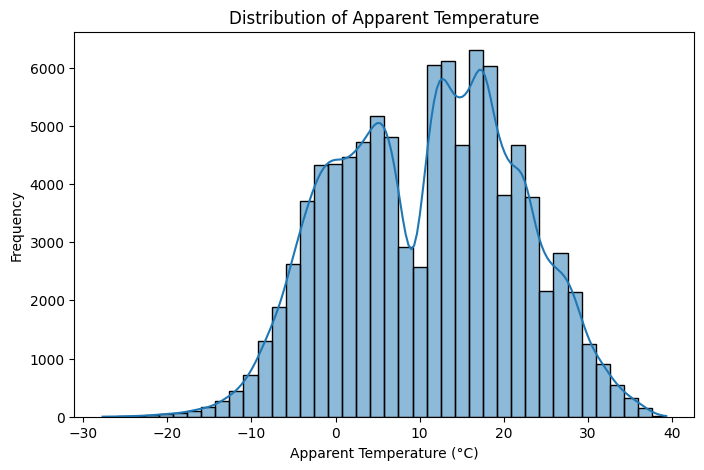

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["Apparent Temperature (C)"],
             bins=40,
             kde=True)

plt.title("Distribution of Apparent Temperature")

plt.xlabel("Apparent Temperature (°C)")

plt.ylabel("Frequency")

plt.show()

#Visualization 2
Temperature Distribution

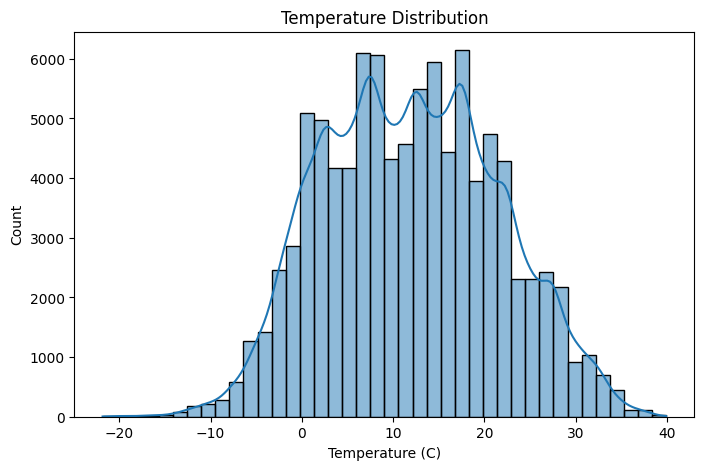

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Temperature (C)"],
             bins=40,
             kde=True)

plt.title("Temperature Distribution")

plt.show()

#Visualization 3
Correlation Heatmap

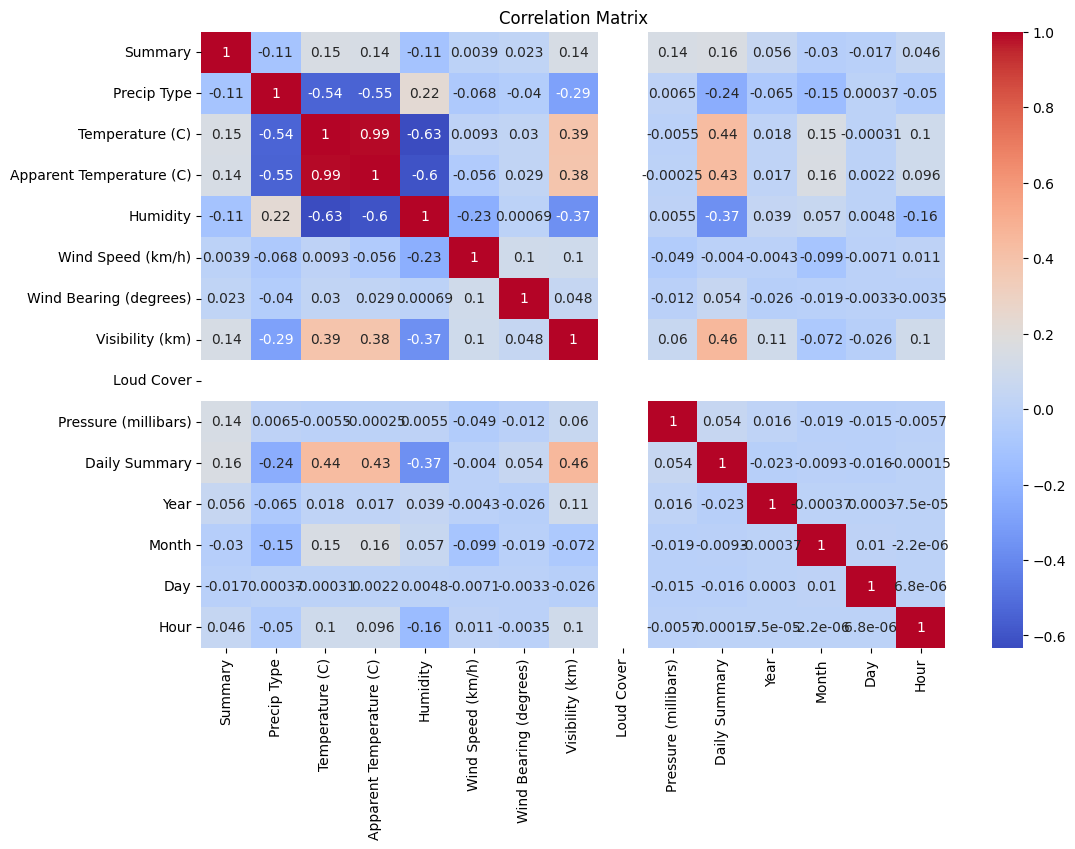

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

#Visualization 4
Boxplot for Target Variable

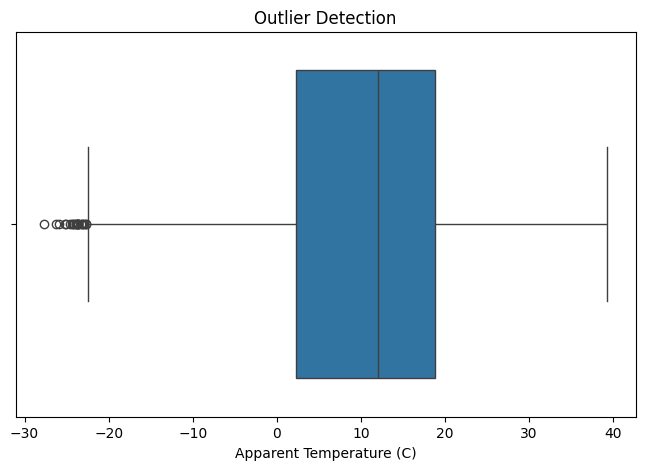

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Apparent Temperature (C)"])

plt.title("Outlier Detection")

plt.show()

#Visualization 5
Scatter Plot

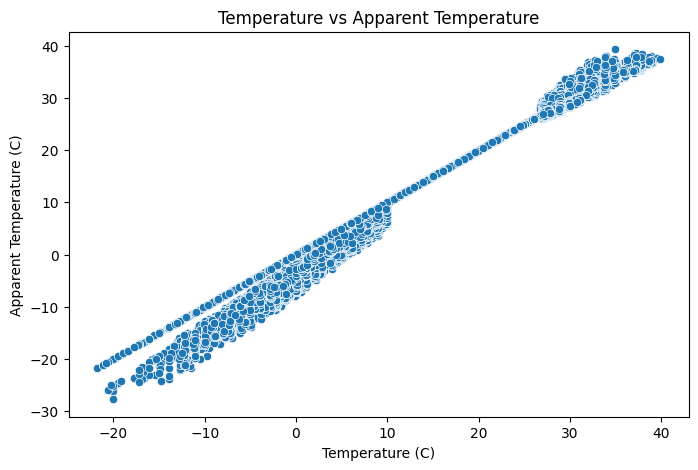

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Temperature (C)",
    y="Apparent Temperature (C)",
    data=df
)

plt.title("Temperature vs Apparent Temperature")

plt.show()

#Visualization 6
Humidity Distribution

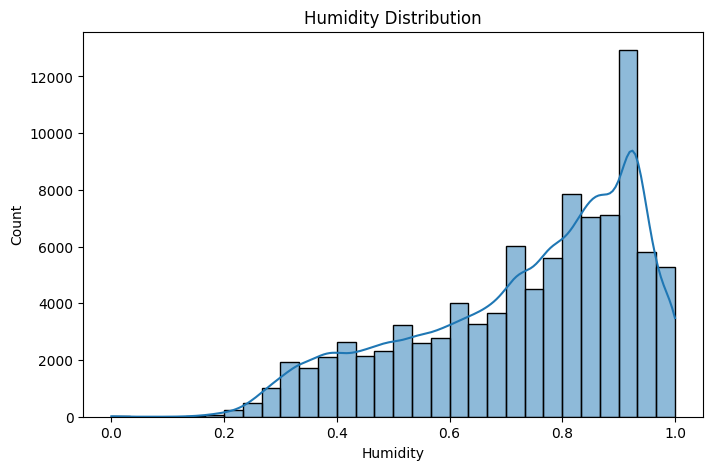

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["Humidity"],
             bins=30,
             kde=True)

plt.title("Humidity Distribution")

plt.show()

#Visualization 7
Wind Speed Distribution

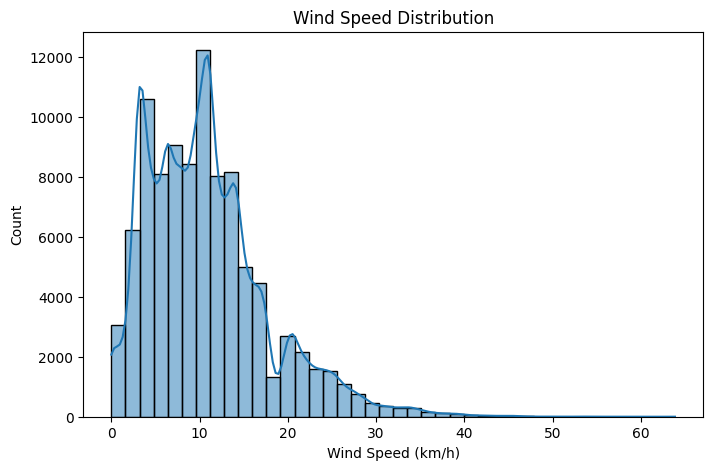

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["Wind Speed (km/h)"],
             bins=40,
             kde=True)

plt.title("Wind Speed Distribution")

plt.show()

#Visualization 8
Visibility Distribution

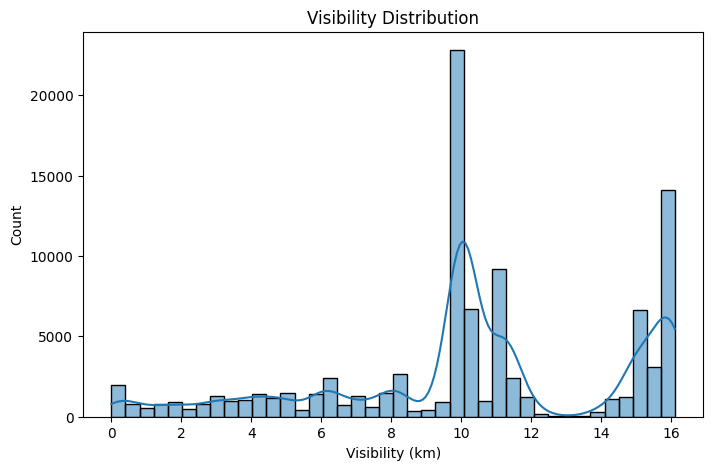

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["Visibility (km)"],
             bins=40,
             kde=True)

plt.title("Visibility Distribution")

plt.show()

#Visualization 9
Pair Plot

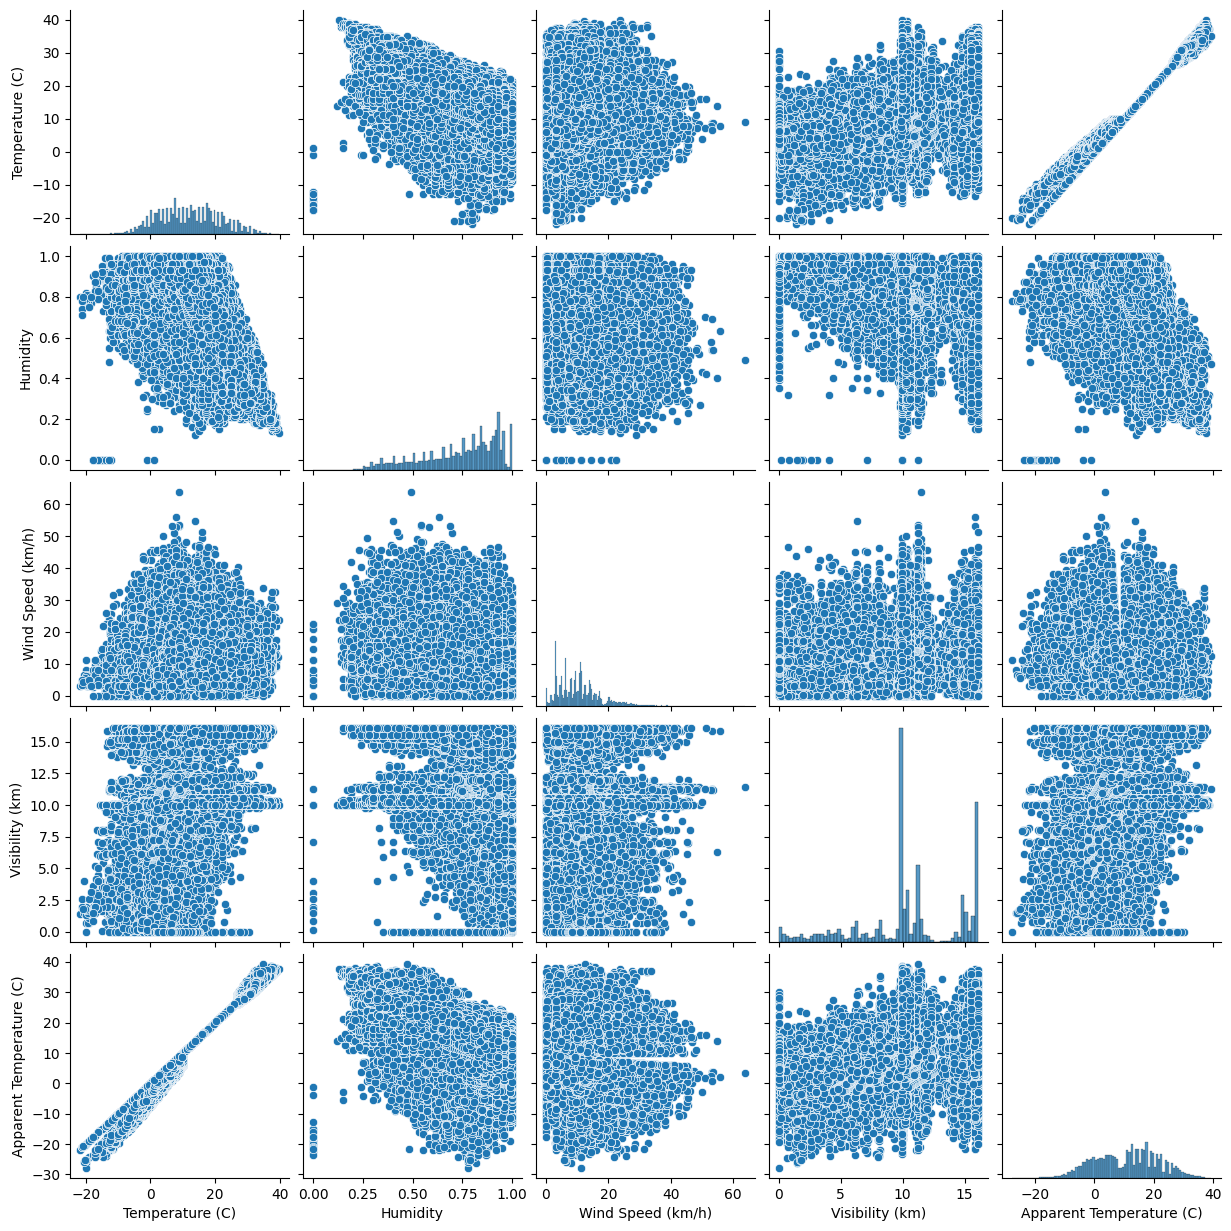

In [40]:
sns.pairplot(df[[
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Visibility (km)",
    "Apparent Temperature (C)"
]])

plt.show()

#Visualization 10
Monthly Temperature Trend

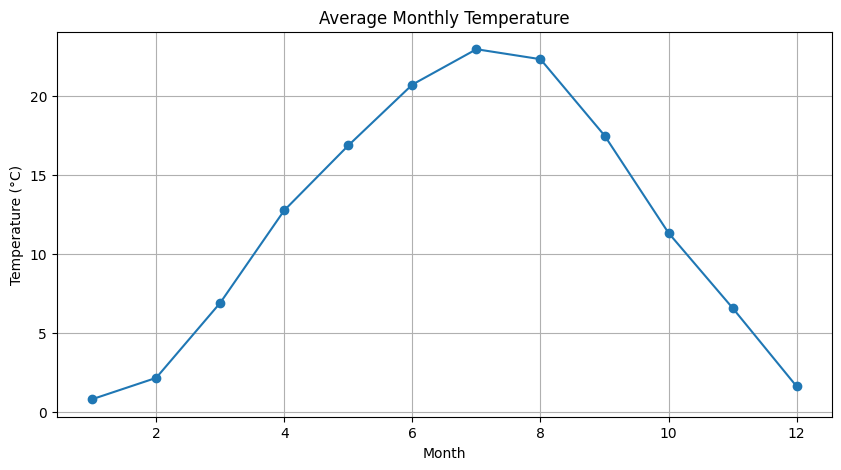

In [41]:
monthly_temp = df.groupby("Month")["Temperature (C)"].mean()

plt.figure(figsize=(10,5))

monthly_temp.plot(marker="o")

plt.title("Average Monthly Temperature")

plt.xlabel("Month")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

# Data Preprocessing

Before training machine learning models, the dataset is prepared by:
- Selecting input features and target variable
- Splitting into training and testing sets
- Standardizing numerical features

# SELECT FEATURES AND TARGET

In [42]:
target = "Apparent Temperature (C)"

X = df.drop(columns=[target, "Formatted Date"])
y = df[target]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (96429, 14)
Target Shape: (96429,)


# SPLIT DATASET

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 77143
Testing Samples : 19286


# STANDARDIZE FEATURES

In [44]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed.")

Scaling Completed.


#SECTION 11: Neural Network Regression (MLPRegressor)

# Neural Network Regression

A Multi-Layer Perceptron (MLP) Regressor is used to predict the Apparent Temperature.

Architecture:
- Hidden Layer: 100 neurons
- Activation: ReLU
- Optimizer: Adam
- Maximum Iterations: 500

In [45]:
# ==========================================================
# BUILD MLP REGRESSOR
# ==========================================================

mlp = MLPRegressor(

    hidden_layer_sizes=(100,),

    activation='relu',

    solver='adam',

    learning_rate='adaptive',

    max_iter=500,

    random_state=42
)

In [46]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

mlp.fit(X_train_scaled, y_train)

print("Neural Network Training Completed.")

Neural Network Training Completed.


In [47]:
# ==========================================================
# MAKE PREDICTIONS
# ==========================================================

mlp_predictions = mlp.predict(X_test_scaled)

In [48]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

mlp_mae = mean_absolute_error(y_test, mlp_predictions)

mlp_mse = mean_squared_error(y_test, mlp_predictions)

mlp_rmse = np.sqrt(mlp_mse)

mlp_r2 = r2_score(y_test, mlp_predictions)

print("="*50)

print("Neural Network Performance")

print("="*50)

print("Mean Absolute Error :", mlp_mae)

print("Mean Squared Error :", mlp_mse)

print("Root Mean Squared Error :", mlp_rmse)

print("R2 Score :", mlp_r2)

Neural Network Performance
Mean Absolute Error : 0.10596930095913391
Mean Squared Error : 0.04167496543155604
Root Mean Squared Error : 0.2041444719593358
R2 Score : 0.9996378891102192


#Display Prediction Table

In [49]:
prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": mlp_predictions

})

prediction_df.head(15)

,Actual,Predicted
0,10.055556,9.109424
1,-0.366667,-0.562528
2,17.688889,17.680446
3,-9.150000,-9.838020
4,27.461111,27.298302
5,27.344444,27.221993
6,25.072222,25.118966
7,17.222222,17.195460
8,17.388889,17.205427
9,3.494444,3.515765


#Actual vs Predicted Scatter Plot

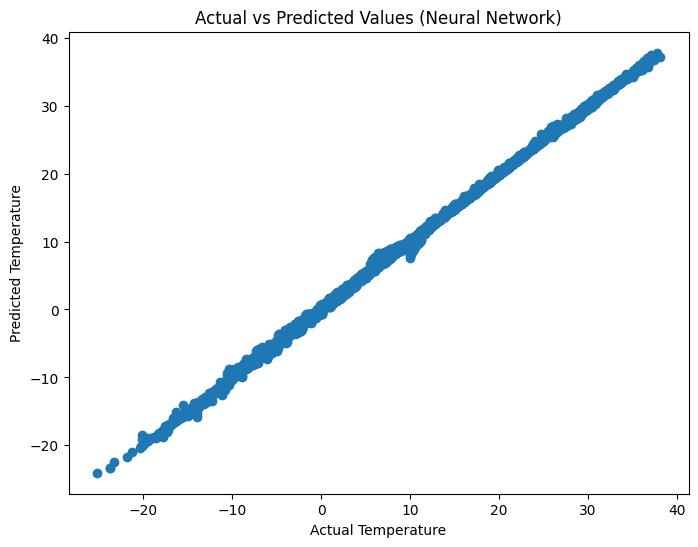

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            mlp_predictions)

plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Values (Neural Network)")

plt.show()

#Residual Plot

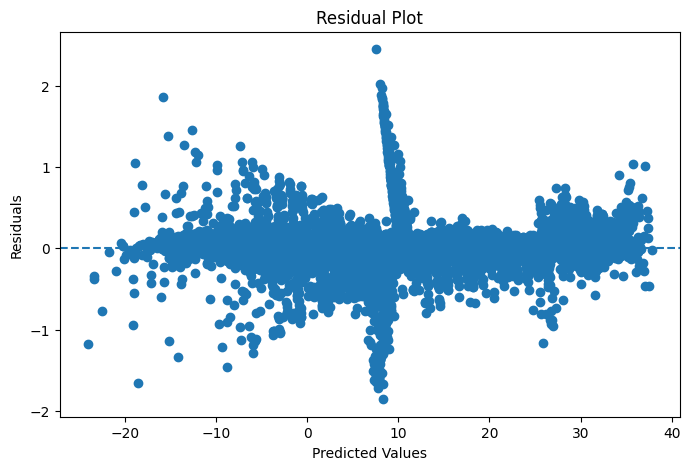

In [51]:
residuals = y_test - mlp_predictions

plt.figure(figsize=(8,5))

plt.scatter(mlp_predictions,
            residuals)

plt.axhline(y=0,
            linestyle="--")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

#Training Loss Curve

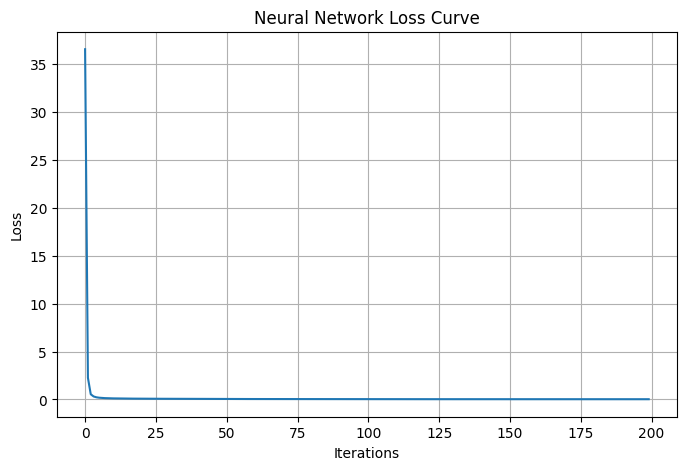

In [52]:
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.title("Neural Network Loss Curve")

plt.grid(True)

plt.show()

#Summary Table

In [53]:
mlp_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],

    "Value":[
        mlp_mae,
        mlp_mse,
        mlp_rmse,
        mlp_r2
    ]

})

mlp_results

,Metric,Value
0,MAE,0.105969
1,MSE,0.041675
2,RMSE,0.204144
3,R2 Score,0.999638


# Linear Regression

Linear Regression is a statistical algorithm that models the relationship
between independent variables and the target variable using a linear equation.

In [54]:
# ==========================================================
# LINEAR REGRESSION
# ==========================================================

linear_model = LinearRegression()

#Train the Model

In [55]:
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


Prediction

In [56]:
linear_predictions = linear_model.predict(X_test_scaled)

Evaluation

In [57]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_predictions)

print("="*50)
print("Linear Regression Results")
print("="*50)

print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE :", linear_rmse)
print("R² :", linear_r2)

Linear Regression Results
MAE : 0.8471577846212984
MSE : 1.1579084814060951
RMSE : 1.0760615602306844
R² : 0.9899390133586243


Prediction Table

In [58]:
linear_results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": linear_predictions

})

linear_results.head(10)

,Actual,Predicted
0,10.055556,8.689968
1,-0.366667,-2.057319
2,17.688889,17.837385
3,-9.150000,-12.312534
4,27.461111,27.684605
5,27.344444,27.549500
6,25.072222,25.561936
7,17.222222,17.724114
8,17.388889,18.070341
9,3.494444,3.986455


Scatter Plot

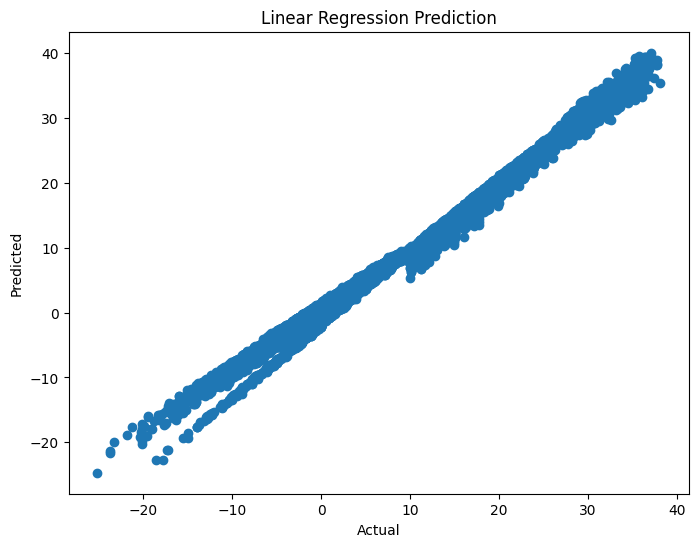

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            linear_predictions)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Linear Regression Prediction")

plt.show()

Residual Plot

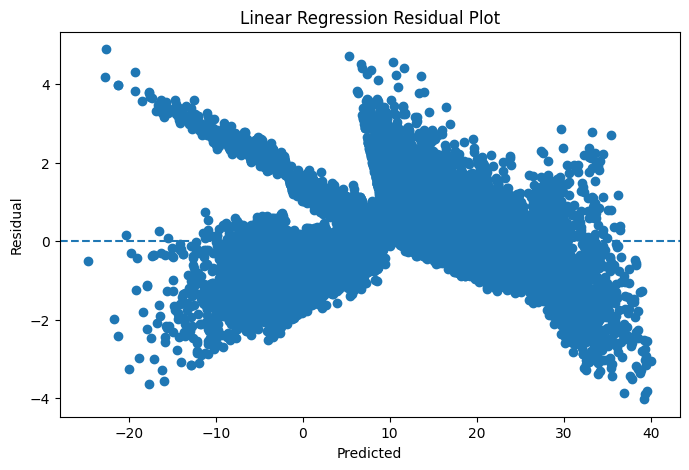

In [60]:
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(8,5))

plt.scatter(linear_predictions,
            linear_residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Linear Regression Residual Plot")

plt.show()

# Random Forest Regression

Random Forest combines multiple decision trees to improve prediction accuracy
and reduce overfitting.

Build Model

In [61]:
random_forest = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

Train Model

In [62]:
random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


Prediction

In [63]:
rf_predictions = random_forest.predict(X_test)

Evaluation

In [64]:
rf_mae = mean_absolute_error(y_test,
                             rf_predictions)

rf_mse = mean_squared_error(y_test,
                            rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test,
                 rf_predictions)

print("="*50)

print("Random Forest Results")

print("="*50)

print("MAE :", rf_mae)

print("MSE :", rf_mse)

print("RMSE :", rf_rmse)

print("R² :", rf_r2)

Random Forest Results
MAE : 0.015612836599958177
MSE : 0.003916914699366144
RMSE : 0.06258525944155016
R² : 0.9999659661993167


Prediction Table

In [65]:
rf_table = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": rf_predictions

})

rf_table.head(10)

,Actual,Predicted
0,10.055556,10.055556
1,-0.366667,-0.369167
2,17.688889,17.688889
3,-9.150000,-9.179500
4,27.461111,27.469444
5,27.344444,27.346611
6,25.072222,25.072222
7,17.222222,17.222222
8,17.388889,17.388944
9,3.494444,3.501667


Scatter Plot

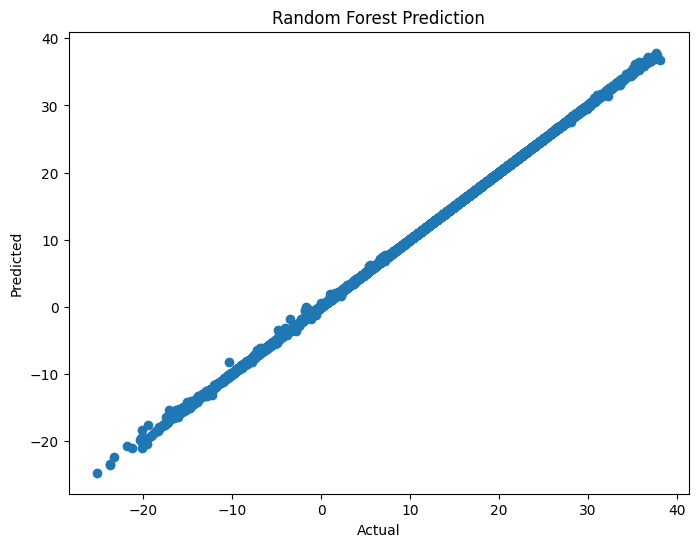

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            rf_predictions)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Random Forest Prediction")

plt.show()

Residual Plot

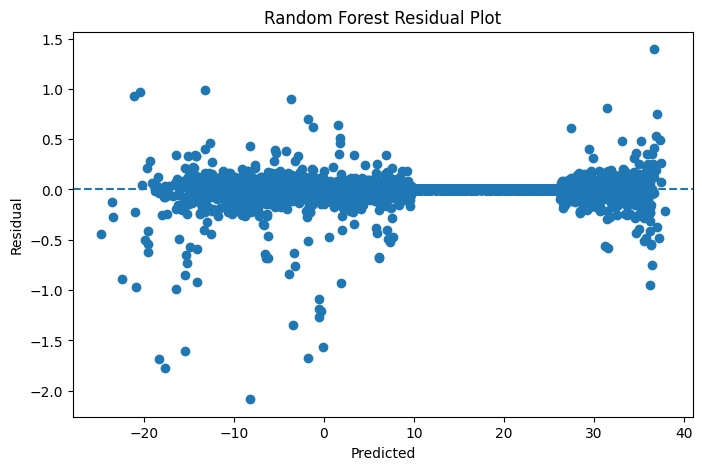

In [67]:
rf_residual = y_test-rf_predictions

plt.figure(figsize=(8,5))

plt.scatter(rf_predictions,
            rf_residual)

plt.axhline(0,
            linestyle="--")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Random Forest Residual Plot")

plt.show()

Feature Importance

In [68]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":random_forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Temperature (C),9.898184e-01
4,Wind Speed (km/h),9.661588e-03
3,Humidity,4.900497e-04
8,Pressure (millibars),4.999906e-06
5,Wind Bearing (degrees),4.583104e-06
6,Visibility (km),4.430400e-06
13,Hour,4.342975e-06
12,Day,2.974805e-06
9,Daily Summary,2.520472e-06
11,Month,2.250292e-06


Feature Importance Plot

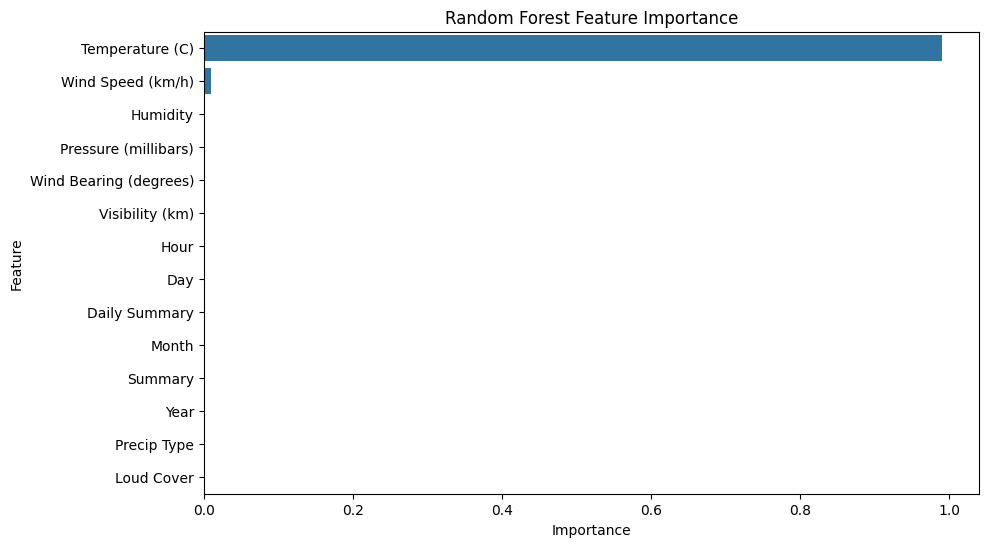

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")

plt.show()

#SECTION 14: Compare Models

In [70]:
comparison = pd.DataFrame({

    "Model":[

        "Neural Network",

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        mlp_mae,

        linear_mae,

        rf_mae

    ],

    "MSE":[

        mlp_mse,

        linear_mse,

        rf_mse

    ],

    "RMSE":[

        mlp_rmse,

        linear_rmse,

        rf_rmse

    ],

    "R²":[

        mlp_r2,

        linear_r2,

        rf_r2

    ]

})

comparison

,Model,MAE,MSE,RMSE,R²
0,Neural Network,0.105969,0.041675,0.204144,0.999638
1,Linear Regression,0.847158,1.157908,1.076062,0.989939
2,Random Forest,0.015613,0.003917,0.062585,0.999966


Performance Visualization

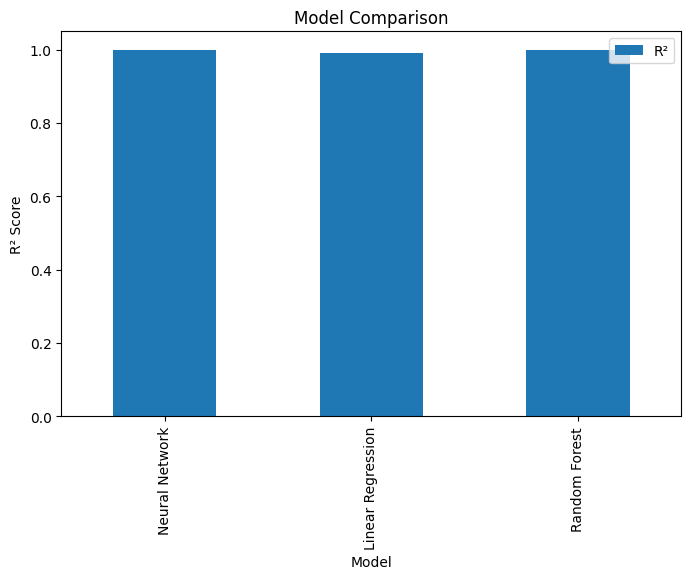

In [71]:
comparison.plot(

    x="Model",

    y="R²",

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("R² Score")

plt.title("Model Comparison")

plt.show()

SECTION 15: Hyperparameter Optimization

# Hyperparameter Optimization

Hyperparameter optimization is used to find the best combination of parameters that improve model performance.

GridSearchCV performs an exhaustive search over different parameter combinations using cross-validation.

In [ ]:
# ==========================================================
# RANDOM FOREST GRID SEARCH
# ==========================================================

rf_parameters = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

rf_grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=rf_parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

rf_grid.fit(X_train,y_train)

print("Best Parameters")

print(rf_grid.best_params_)

print()

print("Best Cross Validation Score")

print(rf_grid.best_score_)

Best Random Forest

In [ ]:
best_rf = rf_grid.best_estimator_

best_rf_predictions = best_rf.predict(X_test)

Evaluation

In [ ]:
best_rf_mae = mean_absolute_error(y_test,best_rf_predictions)

best_rf_mse = mean_squared_error(y_test,best_rf_predictions)

best_rf_rmse = np.sqrt(best_rf_mse)

best_rf_r2 = r2_score(y_test,best_rf_predictions)

print("MAE :",best_rf_mae)

print("MSE :",best_rf_mse)

print("RMSE :",best_rf_rmse)

print("R2 :",best_rf_r2)

#SECTION 16
Hyperparameter Optimization (MLP)

In [ ]:
mlp_parameters = {

    "hidden_layer_sizes":[

        (50,),

        (100,),

        (100,50)

    ],

    "activation":[

        "relu",

        "tanh"

    ],

    "solver":[

        "adam"

    ],

    "learning_rate":[

        "constant",

        "adaptive"

    ]

}

Grid Search

In [ ]:
mlp_grid = GridSearchCV(

    estimator=MLPRegressor(

        max_iter=500,

        random_state=42

    ),

    param_grid=mlp_parameters,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

mlp_grid.fit(

    X_train_scaled,

    y_train

)

print("Best Parameters")

print(mlp_grid.best_params_)

Best Neural Network

In [ ]:
best_mlp = mlp_grid.best_estimator_

best_predictions = best_mlp.predict(X_test_scaled)

Evaluation

In [ ]:
best_mlp_mae = mean_absolute_error(

    y_test,

    best_predictions

)

best_mlp_mse = mean_squared_error(

    y_test,

    best_predictions

)

best_mlp_rmse = np.sqrt(best_mlp_mse)

best_mlp_r2 = r2_score(

    y_test,

    best_predictions

)

print("MAE :",best_mlp_mae)

print("MSE :",best_mlp_mse)

print("RMSE :",best_mlp_rmse)

print("R2 :",best_mlp_r2)

#SECTION 17
Feature Selection
SelectKBest

In [ ]:
selector = SelectKBest(

    score_func=f_regression,

    k=8

)

X_new = selector.fit_transform(X,y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

#Scores

In [ ]:
feature_scores = pd.DataFrame({

    "Feature":X.columns,

    "Score":selector.scores_

})

feature_scores = feature_scores.sort_values(

    by="Score",

    ascending=False

)

feature_scores

Plot

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Score",

    y="Feature",

    data=feature_scores

)

plt.title("SelectKBest Feature Scores")

plt.show()

Recursive Feature Elimination (RFE)

In [ ]:
rfe = RFE(

    estimator=LinearRegression(),

    n_features_to_select=8

)

rfe.fit(X,y)

selected = X.columns[rfe.support_]

print(selected)

Train Using Selected Features

In [ ]:
X_selected = df[selected]

X_train_fs,X_test_fs,y_train_fs,y_test_fs = train_test_split(

    X_selected,

    y,

    test_size=0.20,

    random_state=42

)

Scale

In [ ]:
scaler_fs = StandardScaler()

X_train_fs = scaler_fs.fit_transform(X_train_fs)

X_test_fs = scaler_fs.transform(X_test_fs)

Train Optimized Neural Network

In [ ]:
best_mlp.fit(

    X_train_fs,

    y_train_fs

)

prediction_fs = best_mlp.predict(

    X_test_fs

)

print("Feature Selection R2")

print(r2_score(

    y_test_fs,

    prediction_fs

))

Final Comparison Table

In [ ]:
optimized_results = pd.DataFrame({

    "Model":[

        "Original Neural Network",

        "Optimized Neural Network",

        "Original Random Forest",

        "Optimized Random Forest"

    ],

    "R2":[

        mlp_r2,

        best_mlp_r2,

        rf_r2,

        best_rf_r2

    ],

    "RMSE":[

        mlp_rmse,

        best_mlp_rmse,

        rf_rmse,

        best_rf_rmse

    ]

})

optimized_results

Plot

In [ ]:
optimized_results.plot(

    x="Model",

    y="R2",

    kind="bar",

    figsize=(9,5)

)

plt.ylabel("R2 Score")

plt.title("Optimized Model Comparison")

plt.show()

# Best Model Selection

The model with the highest R² score and the lowest MAE/RMSE is selected as the final regression model.

In [ ]:
# ==========================================================
# BEST MODEL SELECTION
# ==========================================================

final_results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Neural Network",
        "Optimized Random Forest",
        "Optimized Neural Network"
    ],

    "MAE":[
        linear_mae,
        rf_mae,
        mlp_mae,
        best_rf_mae,
        best_mlp_mae
    ],

    "RMSE":[
        linear_rmse,
        rf_rmse,
        mlp_rmse,
        best_rf_rmse,
        best_mlp_rmse
    ],

    "R2 Score":[
        linear_r2,
        rf_r2,
        mlp_r2,
        best_rf_r2,
        best_mlp_r2
    ]

})

final_results

Sort Results

In [ ]:
final_results = final_results.sort_values(
    by="R2 Score",
    ascending=False
)

final_results

Best Model

In [ ]:
best_model = final_results.iloc[0]

print("="*50)

print("Best Regression Model")

print("="*50)

print(best_model)

Final Prediction Visualization

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_rf_predictions
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Best Model Predictions")

plt.grid(True)

plt.show()

Residual Analysis

In [ ]:
residual = y_test - best_rf_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    best_rf_predictions,
    residual
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.show()

Residual Distribution

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    residual,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

Final Performance Comparison

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="R2 Score",

    data=final_results

)

plt.xticks(rotation=20)

plt.title("Final Model Comparison")

plt.show()

RMSE Comparison

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="RMSE",

    data=final_results

)

plt.xticks(rotation=20)

plt.title("RMSE Comparison")

plt.show()

Load Model

In [ ]:
loaded_model = joblib.load("best_weather_model.pkl")

Conclusion


# Conclusion

The objective of this project was to predict Apparent Temperature using regression algorithms.

Three regression models were implemented:

- Linear Regression
- Random Forest Regression
- Multi-Layer Perceptron Neural Network

Hyperparameter tuning and feature selection were applied to improve performance.

Among all models, the Optimized Random Forest achieved the highest R² score with the lowest prediction error, making it the most suitable model for this dataset.

The project demonstrates that ensemble learning methods outperform simple linear regression for complex weather datasets.

# Reflection

During this project, I learned the complete workflow of a machine learning regression problem.

The project involved:

- Data cleaning
- Exploratory Data Analysis
- Feature Engineering
- Feature Selection
- Model Building
- Hyperparameter Optimization
- Performance Evaluation

One challenge was selecting appropriate hyperparameters while avoiding overfitting.

Future work could include testing advanced boosting algorithms such as XGBoost or LightGBM and exploring deep learning architectures with TensorFlow or PyTorch.

Final Display

In [ ]:
print("="*70)

print("REGRESSION PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print()

print(final_results)

print()

print("Best Model")

print(best_model["Model"])